In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style("darkgrid")

## Libraries used:
`statsmodel` - useful for insights.

`scikit-learn` - usefule for predictions.

# Introducing Regression
At its core, regression is a statistical method used to model the relationship between a dependent variable (the outcome you want to predict) and one or more independent variables (the features or predictors).

* Dependent variable/ response variable --> the value to be predicted
* Independent variable/ explanatory variable --> The variables that explain how the dependent variables will change



# Linear Regression

Linear regression is a method to model the relationship between variables by fitting a straight-line equation (or linear combination) that predicts a continuous value.

Modeling the relationship using a linear equation: _`y = mx + b`_ .<br>
here, the **intercept (_b_)** --> is y-value when x=0<br>
and **slope (_m_)** --> the amount by which y-value increases for one increase in _x-value_


### Example: Analyzing an ad spend 
We try to correlate ad spends to the returns on investments in terms of engagement (no. of clicks) on those ads.<br>
Here, ad_spend is the independent/ explanatory variable that explain the dependent/ response variable - no. of clicks.

**Impressions** are the total number of times your content is displayed, no matter if it was clicked or not.<br>
**Reach** is the total number of unique users who see your content.<br>
**Engagement** is the total number of times users interact with your content. This could be likes, comments, shares and **clicks**.

In [2]:
# importing a dataset
cnvrsn_df = pd.read_csv('./datasets/ad_conversion.csv')
cnvrsn_df.head()

,spent_usd,n_impressions,n_clicks
0,1.43,7350,1
1,1.82,17861,2
2,1.25,4259,1
3,1.29,4133,1
4,4.77,15615,3


First, we plot the ad_spends vs engagement to perform a visual check on the relationship

Using `sns.regplot()` to plot data and draw a linear regression model fit  **that combines a scatter plot of the data points with a best-fit regression line** to visually emphasize patterns & the relationship between two variables (bivariate analysis).

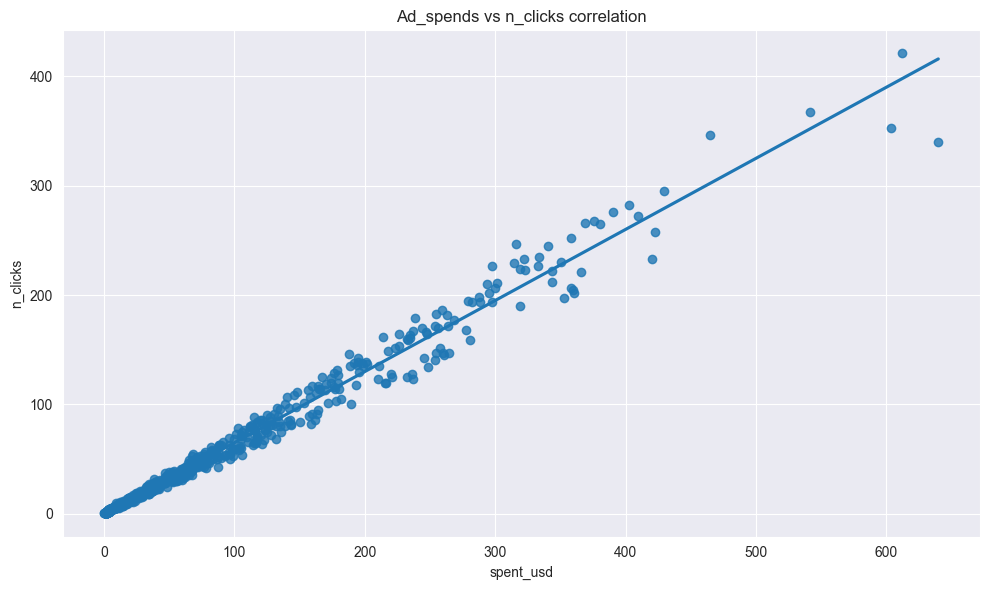

In [3]:
# Visualizing the relationship between the explanatory & response variables
plt.figure(figsize=(10,6))
sns.regplot(data=cnvrsn_df, x='spent_usd' , y='n_clicks', ci=None)
plt.title("Ad_spends vs n_clicks correlation")
plt.tight_layout()
plt.show()

### Running a regression test
What is OLS?

In [4]:
# Importing the OLS module
from statsmodels.formula.api import ols

mdl = ols("spent_usd ~ n_clicks", data= cnvrsn_df)
mdl = mdl.fit()
print(type(mdl))

<class 'statsmodels.regression.linear_model.RegressionResultsWrapper'>


In [5]:
mdl.params

Intercept    0.946359
n_clicks     1.514986
dtype: float64

**Result of the `params` shows that:**

The intercept (_b_) is at 0.95 - This means $0.95 is spent on an ad even when engagement (no. of clicks) is 0.

Slope (_m_) is about 1.5 - for every 1 unit of increase in user engagement (n_clicks), likely expense on ad rises by `(1.5 per n_click)`



_____
## Linear regression with Categorical ex-variables
In case of >1 explanatory variables that are Categorical, **the coefficients are simply the means of the categories**.

Instead of passing a single Series (one column) as X, you pass a Matrix (multiple columns). statsmodels handles this by calculating the coefficients for every column provided.

Mathematically, the simple linear equation expands to a multidimensional plane (or hyperplane).<br>
So y = mx + b` becomes **y = b + m <sub>1</sub> x + m <sub>2</sub> x + m <sub>3</sub> x + ...**

In [6]:
# Importing the fisheries data
fisheries_df = pd.read_csv("./datasets/fish.csv")
fisheries_df.head(2)

,species,mass_g,length_cm
0,Bream,242.0,23.2
1,Bream,290.0,24.0


In [7]:
# Notice that species is categorical data
print(fisheries_df["species"].nunique())
print(fisheries_df["species"].unique())

4
['Bream' 'Roach' 'Perch' 'Pike']


The dataset basically contains 4 species. Since we have a categorical explanatory variable, visualizing relationship with a scatterplot is not ideal.

Scatterplots are **specifically designed for two continuous variables**. If a continuous variable is plotted against a categorical variable,it'll lead to issues with interpretation, overplotting, and lack of clarity on distributional differences.

As categorical variables have discrete, limited values, a scatterplot will align all data points into vertical or horizontal lines. If the dataset is large, these points will overlap (overplot), making it impossible to see the density of data within each category.

Also, scatterplot shows raw data points, making it difficult to compare mean/ median/ spread or skewness across different categories in a single scatterplot visual.

Thus, it makes sense to use other visualization methods such as plot distribution, box plots etc. to plot distribution of the response variable for each of the categories. `sns.displot` is one such method that can be used for this category-wise distribution mapping. 

<Figure size 1000x800 with 0 Axes>

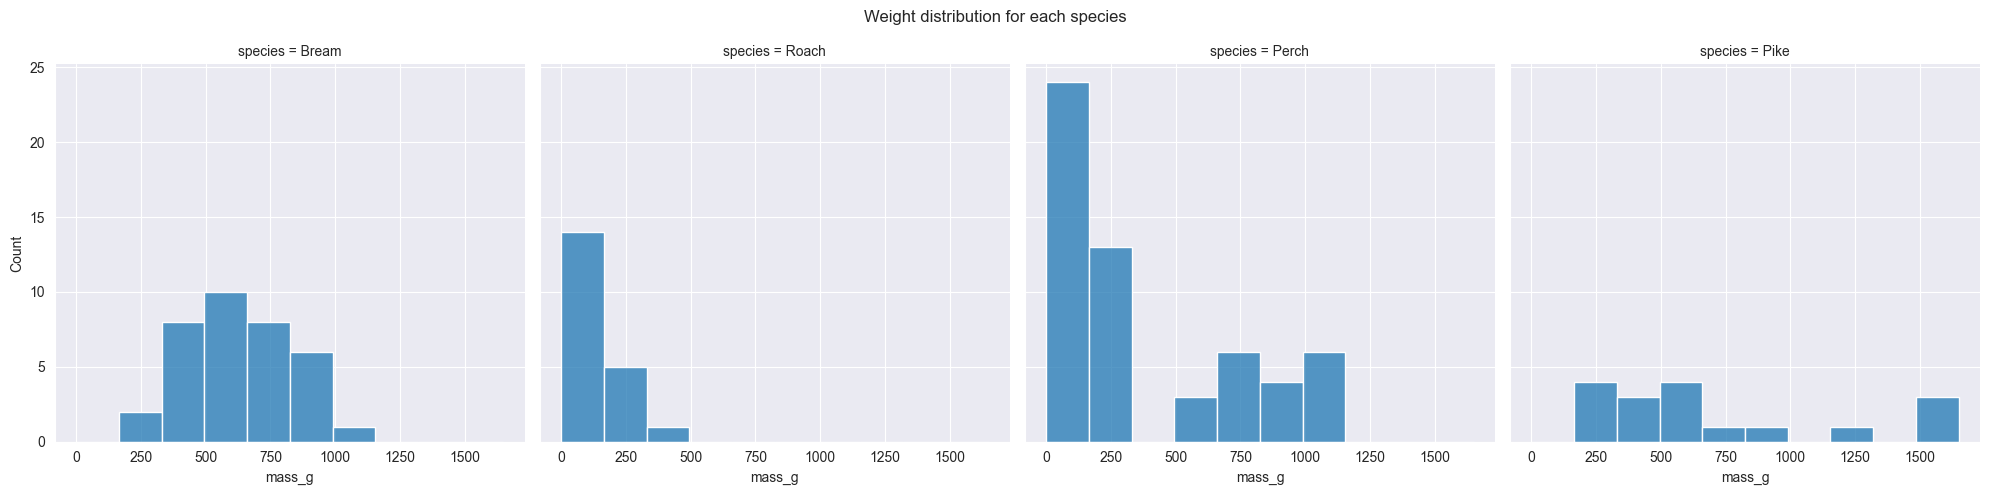

species
Bream    617.83
Perch    382.24
Pike     718.71
Roach    152.05
Name: mass_g, dtype: float64

In [8]:
# Visualizing distribution for each category
plt.figure(figsize = (10,8))
sns.displot(data= fisheries_df, x="mass_g" , col="species", bins=10)
plt.suptitle("Weight distribution for each species")
plt.tight_layout()
plt.show()

# Confirming the visualization using summary stats
fisheries_df.groupby("species")["mass_g"].mean().round(2) 


**If Regression is done with intercept (default):**
* One species is used as the reference category to avoid multicollinearity
* The other coefficients represent differences from the reference<br>
e.g.: `species[Perch] = -235` would mean "Perch weighs 235g less than Bream"

In [9]:
fisheries_mdl = ols("mass_g ~ species", data = fisheries_df).fit()
fisheries_mdl.params

Intercept           617.828571
species[T.Perch]   -235.589286
species[T.Pike]     100.877311
species[T.Roach]   -465.778571
dtype: float64

**Why remove the intercept (+ 0)?**<br>
* All species are kept — no reference category is dropped
* Each coefficient **directly equals the mean mass of that species**<br>
e.g.: `species[Bream] = 617.83` means the average Bream weighs ~618g

>By adding `+ 0` to the `formula`, you're telling `statsmodels` (using the `formula.api` style):<br>
_"Do not use a reference category. Show me the absolute mean for every single group."_

In [10]:
fisheries_mdl = ols("mass_g ~ species + 0", data = fisheries_df).fit()
print(f"Co-efficients after adding 0:\n{fisheries_mdl.params}\n")

# Each coefficient directly equals the mean mass of that species
fisheries_meanmass = fisheries_df.groupby("species")["mass_g"].mean().round(2) 
print(f"Result is same as mean mass of the species:\n{fisheries_meanmass}\n")

Co-efficients after adding 0:
species[Bream]    617.828571
species[Perch]    382.239286
species[Pike]     718.705882
species[Roach]    152.050000
dtype: float64

Result is same as mean mass of the species:
species
Bream    617.83
Perch    382.24
Pike     718.71
Roach    152.05
Name: mass_g, dtype: float64



## Making predictions
Using an explanatory variable to predict value of another variable.

> _"If I set the explanatory variable to some value, what value would response variable have?"_

### Example: from the `fisheries` dataset, using length to predict mass of the fish species

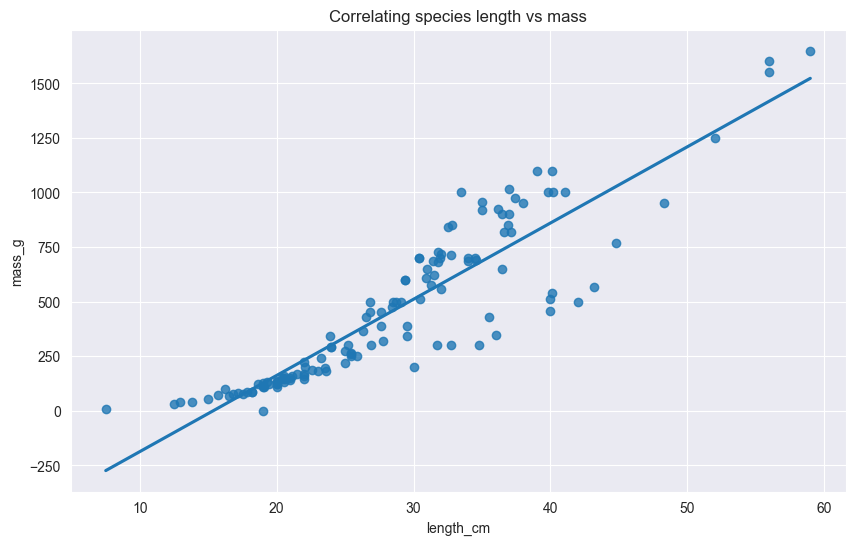

In [11]:
# visualizing relation between length & mass
plt.figure(figsize=(10,6))
sns.regplot(data=fisheries_df, x= "length_cm", y="mass_g", ci=None)
plt.title("Correlating species length vs mass" )
plt.show()

### Step-1: Running the linear regression model for the _Bream_ species

In [12]:
# Creating a df subset for the bream species
bream_sp = fisheries_df[fisheries_df["species"]=="Bream"].copy()
# Running the model for mass vs length
mdl_mass_length = ols("mass_g ~ length_cm", data=bream_sp).fit()

# Checking the coefficients
mdl_mass_length.params

Intercept   -1035.347565
length_cm      54.549981
dtype: float64

### Step-2 Creating a sample df of explanatory data

In [13]:
# Creating sample df containins length calues form 20 - 30 cm
ex_vars = pd.DataFrame({"length_cm": np.arange(20,41)})
ex_vars.head()

,length_cm
0,20
1,21
2,22
3,23
4,24


### Step-3: Using the `predict` method
NOTE: When using the formula API (`ols`), the DataFrame you pass into `.predict()` must **have column names that exactly match** the independent variables used to train the model.

The result in this case will be a pandas series

Add this series & the sample **ex_vars** df, either using `df.assign()` function to a new dataframe OR to existing dataframe to enable comparison alongside the explanatory variables 

In [14]:
# Predicting values based on the linear regression model
mdl_mass_length.predict(ex_vars)

0       55.652054
1      110.202035
2      164.752015
3      219.301996
4      273.851977
5      328.401958
6      382.951939
7      437.501920
8      492.051901
9      546.601882
10     601.151863
11     655.701844
12     710.251825
13     764.801806
14     819.351787
15     873.901768
16     928.451749
17     983.001730
18    1037.551710
19    1092.101691
20    1146.651672
dtype: float64

In [15]:
print(type(mdl_mass_length.predict(ex_vars)))

<class 'pandas.core.series.Series'>


In [16]:
prediction_data = ex_vars.assign(mass_g = mdl_mass_length.predict(ex_vars))
print(prediction_data)
print(type(prediction_data))

    length_cm       mass_g
0          20    55.652054
1          21   110.202035
2          22   164.752015
3          23   219.301996
4          24   273.851977
5          25   328.401958
6          26   382.951939
7          27   437.501920
8          28   492.051901
9          29   546.601882
10         30   601.151863
11         31   655.701844
12         32   710.251825
13         33   764.801806
14         34   819.351787
15         35   873.901768
16         36   928.451749
17         37   983.001730
18         38  1037.551710
19         39  1092.101691
20         40  1146.651672
<class 'pandas.core.frame.DataFrame'>


### Step-4: Visualizing the predictions 
Comparing training & testing data

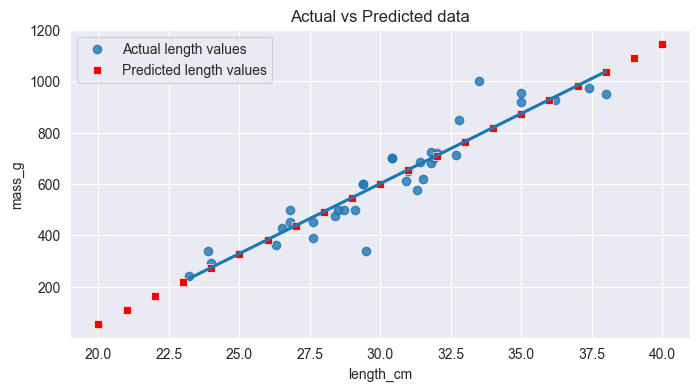

In [17]:
fig = plt.figure(figsize=(8,4))
sns.regplot(x="length_cm", y="mass_g", data=bream_sp, 
            ci=None, label="Actual length values")

sns.scatterplot(data=prediction_data, x="length_cm", y="mass_g", 
                color='red', marker='s', label="Predicted length values")

plt.legend()
plt.title("Actual vs Predicted data")
plt.show()

## Extrapolating predictions


In [18]:
# finding highest length value from species df
bream_sp["length_cm"].max()

np.float64(38.0)

In [19]:
# Predicting species mass for length higher than 38
max_bream_sp = pd.DataFrame({"length_cm": [45]})

max_bream_sp["predicted_len"] = mdl_mass_length.predict(max_bream_sp)
print(max_bream_sp)

   length_cm  predicted_len
0         45    1419.401577


## Model Objects
**`.fittedvalues`** -  is just the line evaluated at your data points. The model's predicted y-values for each observation in your training data, based on its x-value plugged into the regression equation. The regression line is the set of all predicted ŷ values — for every possible x, not just the observed ones.

For every _x_ value in your original dataset: The model finds that $x$ on the horizontal axis.It moves vertically until it hits the regression line.The y-coordinate at that specific point on the line is the fitted value ($\hat{y}$).

**`.resid`** - the vertical "gap" or distance between the actual point and your fitted value


In [20]:
# Fitted values -- predictions on the original dataset
mdl_mass_length.fittedvalues
# Equivalent to 
mdl_mass_length.predict(bream_sp["length_cm"])

assert mdl_mass_length.fittedvalues.equals(mdl_mass_length.predict(bream_sp["length_cm"]))

In [21]:
# Residual -- difference between actual vs predicted response values 
mdl_mass_length.resid
# Equivalent to 
bream_sp["mass_g"] - mdl_mass_length.fittedvalues

0      11.788007
1      16.148023
2      71.603021
3     -36.316934
4      19.773070
5      23.408076
6      73.408076
7     -80.231909
8     -20.231909
9     -19.326892
10    -38.871893
11    -30.236888
12    -52.056880
13   -233.876873
14     31.578126
15     31.578126
16     77.028145
17     77.028145
18    -40.246846
19     -5.701844
20    -97.066838
21      7.478164
22    -62.976834
23    -19.341829
24     -4.796827
25     25.658171
26      9.748175
27    -34.436811
28     96.108190
29    207.923204
30     46.098232
31     81.098232
32    -14.361745
33    -29.821722
34    -87.551710
dtype: float64

In [22]:
# Residual -- difference between actual vs predicted response values 
mdl_mass_length.resid
# Equivalent to 
bream_sp["mass_g"] - mdl_mass_length.fittedvalues

0      11.788007
1      16.148023
2      71.603021
3     -36.316934
4      19.773070
5      23.408076
6      73.408076
7     -80.231909
8     -20.231909
9     -19.326892
10    -38.871893
11    -30.236888
12    -52.056880
13   -233.876873
14     31.578126
15     31.578126
16     77.028145
17     77.028145
18    -40.246846
19     -5.701844
20    -97.066838
21      7.478164
22    -62.976834
23    -19.341829
24     -4.796827
25     25.658171
26      9.748175
27    -34.436811
28     96.108190
29    207.923204
30     46.098232
31     81.098232
32    -14.361745
33    -29.821722
34    -87.551710
dtype: float64

In [23]:
mdl_mass_length.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                 mass_g   R-squared:                       0.878
Model:                            OLS   Adj. R-squared:                  0.874
Method:                 Least Squares   F-statistic:                     237.6
Date:                Thu, 09 Apr 2026   Prob (F-statistic):           1.22e-16
Time:                        07:18:06   Log-Likelihood:                -199.35
No. Observations:                  35   AIC:                             402.7
Df Residuals:                      33   BIC:                             405.8
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept  -1035.3476    107.973     -9.589      0.000   -1255.020    -815.676
length_cm     54.5500      3.539     15.415      0.000      47.350      61.750
==============================================================================
Omnibus:                        7.314   Durbin-Watson:                   1.478
Prob(Omnibus):                  0.026   Jarque-Bera (JB):               10.857
Skew:                          -0.252   Prob(JB):                      0.00439
Kurtosis:                       5.682   Cond. No.                         263.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

## Regression to mean
Regression to the Mean (RTTM) is a statistical phenomenon where, if a variable is extreme on its first measurement, it will tend to be closer to the average (the mean) on its second measurement.

>* Extreme outcomes tend to be followed by more moderate ones — not because of any real cause, but simply due to chance/randomness.
>* If someone performs exceptionally well or poorly, their next performance will likely drift back toward the average.

## Why it Matters in Data Science
If you are running a regression model and you see a massive spike or drop in your data, you have to ask: Is this a new trend, or is it just regression to the mean?

## Example: RTTM for ROI on S&P500  

`symbol` - Stock ticker symbol uniquely identifying the company.<br>
`return_2018` - A measure of investment performance in 2018.<br>
`return_2019` - A measure of investment performance in 2019.

In [24]:
sp500_df = pd.read_csv('./datasets/sp500_yearly_returns.csv')
sp500_df.head()

,symbol,return_2018,return_2019
0,AAPL,-0.053902,0.889578
1,MSFT,0.207953,0.575581
2,AMZN,0.284317,0.230278
3,FB,-0.257112,0.565718
4,GOOGL,-0.008012,0.281762


In [25]:
# Apply linear regression & fit the model
sp500_mdl = ols("return_2019 ~ return_2018" , data=sp500_df).fit()
print(f"{sp500_mdl.params}\n")
print(sp500_mdl.fittedvalues)

Intercept      0.321321
return_2018    0.020069
dtype: float64

0      0.320239
1      0.325494
2      0.327027
3      0.316160
4      0.321160
         ...   
488    0.321721
489    0.314032
490    0.325827
491    0.325615
492    0.315407
Length: 493, dtype: float64


Slope (m=0.02) means line is almost parallel to x-axis. This indicates an extremely weak relationship in 2018 & 2019 returns.

Also, Intercept being quite high (~32%) means overall good RoI in 2019, independent of 2018's performance.

So the prediction would be: 
`ŷ = 0.321 + 0.020 × return_2018`

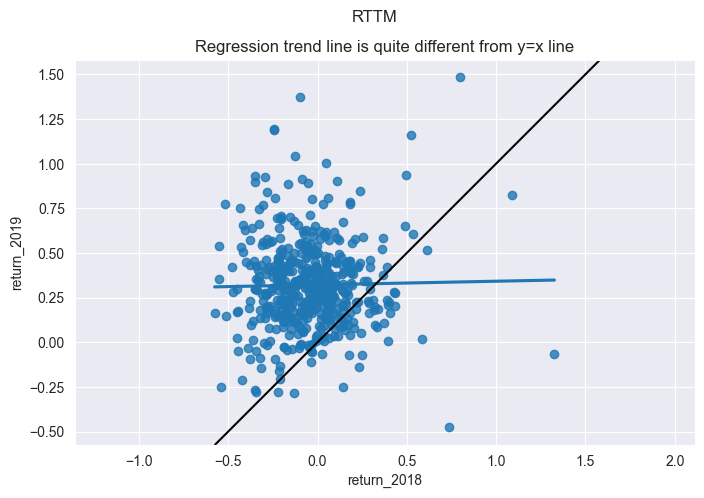

In [26]:
plt.figure(figsize=(8,5))
# Plotting the scatterplot + regression fitted line
sns.regplot(data=sp500_df, x="return_2018", y="return_2019", ci=None)
# Plotting a line with y=x
# indicating ideal scenario that past performance dictates present one
plt.axline(xy1=(0,0), slope=1, color="black")
plt.suptitle("RTTM")
plt.title("Regression trend line is quite different from y=x line")
plt.axis("equal") #equal x & y-axes
plt.show()

The y=x line indicates ideal scenario. Where as regression line shows this is not the case.

Now considering 'what-if' scenarios - one with 100% loss , no change & one for 100% returns

In [27]:
# considering extremely high or low returns in 2018 to see if their performance was similar in 2019.
explanatory_data = pd.DataFrame({"return_2018":[-1, 0, 1]})

# These are not real data points from the dataset — they're manually chosen "what if" scenarios

In [28]:
sp500_mdl.predict(explanatory_data)

0    0.301251
1    0.321321
2    0.341390
dtype: float64

This shows that:<br>
* stocks with extrem loss(-100%) in 2018 still managed to deliver near-average returns in 2019.
* Same is true for other extreme too - stocks with 100% returns in 2018 'ran out of luck' & delivered far lesser returns that were near-average.
* Stocks in both scenarios didn't continue to stay in the extremities -- they converged to the average value of 32% (Intercept value)

Worst 2018 stocks  (−100%) → predicted +30.1% in 2019  ← bounced BACK UP<br>
Flat 2018 stocks   (  0%)  → predicted +32.1% in 2019<br>
Best 2018 stocks   (+100%) → predicted +34.1% in 2019  ← barely higher

____
## Transforming Variables
Linear regression has a key assumption — the relationship between x and y must be linear (a straight line). But real-world data often isn't.

In linear regression, transformation is the process of applying a mathematical function (like $log$, $square \space root$, or $reciprocal$) to your independent or dependent variables before fitting the model.

**Why Transform? (The 3 Main Reasons)**<br>
* **Linearity:** To turn a "curve" into a "line" so the model can actually understand the pattern.
* **Normality:** To make the distribution of your residuals look like a classic "Bell Curve."
* **Homoscedasticity:** To ensure the "errors" (residuals) are roughly the same size at the start of the line and the end of the line.

**Which transformation to apply & when?**
| Variable type | Likely transform |
|---------------|-----------------|
| Salary, revenue, population | `log(y)` — money grows multiplicatively |
| Biological size (mass vs length) | `log(y) ~ log(x)` — power law relationship / apply cube |
| Ad spend vs sales | `y ~ log(x)` — diminishing returns |
| Test scores, proportions | Often fine raw, or `sqrt` |
| Counts (0, 1, 2, 3...) | `sqrt(y)` or Poisson regression |

### Example 1-Predicting mass against length for Perch sub-species


<function matplotlib.pyplot.show(close=None, block=None)>

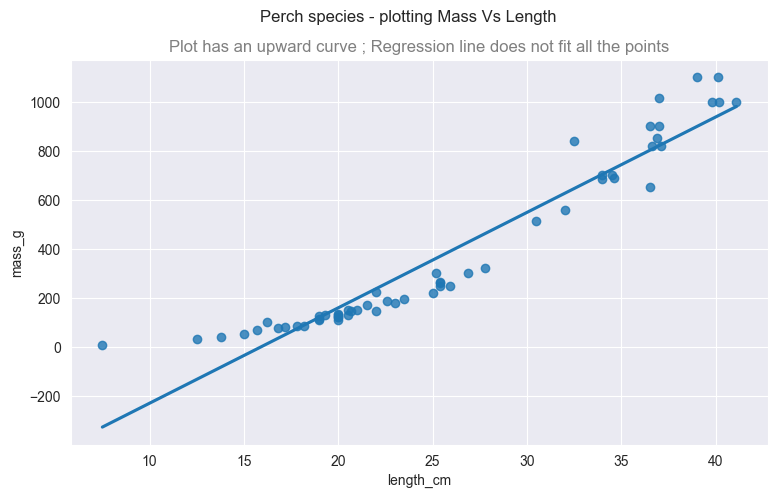

In [29]:
# Creating a subset for Perch species
perch_sp =  fisheries_df[fisheries_df["species"]=="Perch"].copy()

# Visualizing regression plot
plt.figure(figsize=(9,5))
sns.regplot(data=perch_sp, x="length_cm" ,y="mass_g", ci=None)
plt.suptitle("Perch species - plotting Mass Vs Length")
plt.title("Plot has an upward curve ; Regression line does not fit all the points", color='grey')
plt.show

Since the y vs x plot is NON-linear, we'll have to transform the either of x- or y-values so the model is able to fit a line of regression.

Considering a mass vs length distribution for another species (Perch) . We observe that the mass values DO NOT follow a linear relationship to length. If a fish doubles in length ($2x$), its weight doesn't just double ($2y$); it usually increases by eight times ($2^3 = 8$). This is a physical law of geometry.<br>
**Hence, considering $length^3$ makes more sense when to fitting the regression model line.**

So we added a column `length_cm_cb` to the sample df containing cubed values of the species length.

In [30]:
# Adding new column with cbe of the specimen's length
perch_sp["length_cm_cb"] = perch_sp["length_cm"]**3
perch_sp.head()

,species,mass_g,length_cm,length_cm_cb
55,Perch,5.9,7.5,421.875
56,Perch,32.0,12.5,1953.125
57,Perch,40.0,13.8,2628.072
58,Perch,51.5,15.0,3375.000
59,Perch,70.0,15.7,3869.893


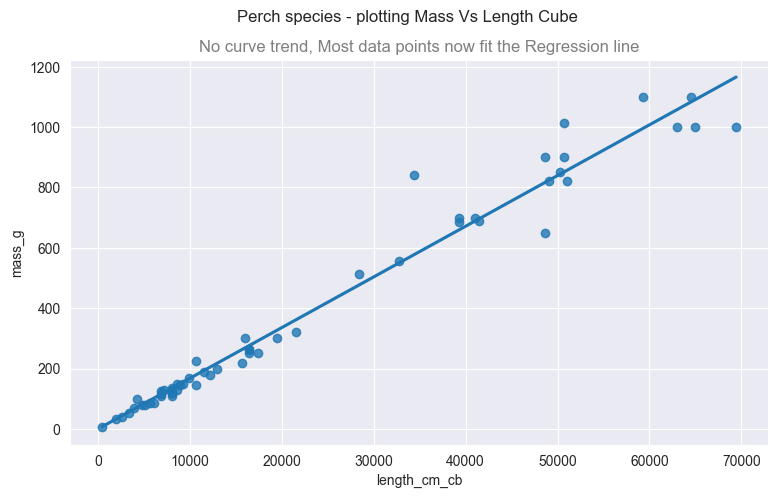

In [31]:
# Now plotting mass against the transformed column
# Visualizing regression plot
plt.figure(figsize=(9,5))
sns.regplot(data=perch_sp, x="length_cm_cb", y="mass_g", ci=None)
plt.suptitle("Perch species - plotting Mass Vs Length Cube")
plt.title("No curve trend, Most data points now fit the Regression line", color='grey')
plt.show()

In [32]:
# Now applying regression model
perch_cblen_mdl =  ols("mass_g ~ length_cm_cb", data = perch_sp).fit()
perch_cblen_mdl.params 

Intercept      -0.117478
length_cm_cb    0.016796
dtype: float64

Slope suggests very low relation to $length^3$. Now testing prediction for sample ex_vars:

In [33]:
# testing prediction for sample ex_vars -- considering 10 different lengths
perch_ex_vars = pd.DataFrame({"length_cm_cb":np.arange(10,41,5)**3,
                              "length_cm":np.arange(10,41,5)})
print(perch_ex_vars)
print("\n")
# Now predicting for above ex_vars
perch_predctn = perch_ex_vars.assign(mass_g = perch_cblen_mdl.predict(perch_ex_vars))
print(perch_predctn) 

   length_cm_cb  length_cm
0          1000         10
1          3375         15
2          8000         20
3         15625         25
4         27000         30
5         42875         35
6         64000         40


   length_cm_cb  length_cm       mass_g
0          1000         10    16.678135
1          3375         15    56.567717
2          8000         20   134.247429
3         15625         25   262.313982
4         27000         30   453.364084
5         42875         35   719.994447
6         64000         40  1074.801781


Plotting for the predicted mass values:

<Figure size 640x480 with 0 Axes>

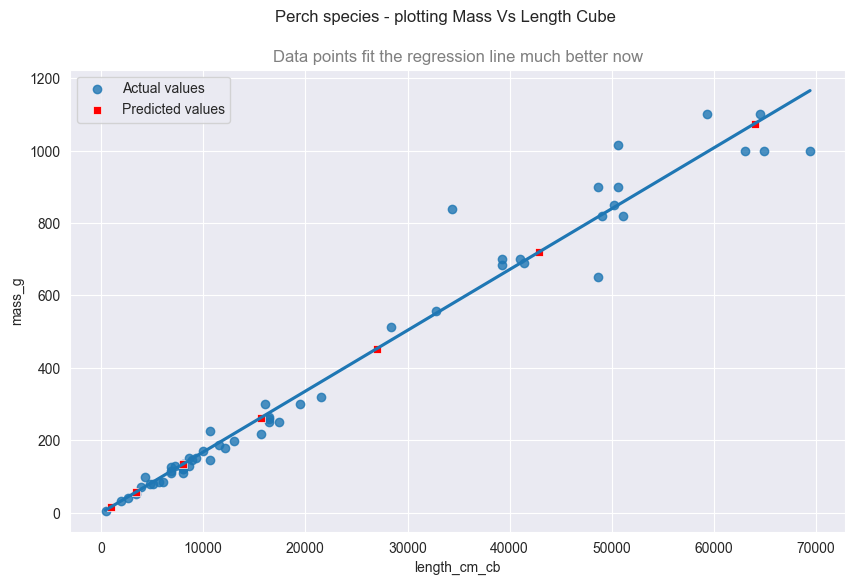

In [34]:
fig = plt.figure()
plt.figure(figsize=(10,6))
sns.regplot(data=perch_sp, x="length_cm_cb", y="mass_g", ci=None, label="Actual values")
sns.scatterplot(data=perch_predctn, x="length_cm_cb", y="mass_g", label="Predicted values", marker="s", color="red")
plt.suptitle("Perch species - plotting Mass Vs Length Cube")
plt.title("Data points fit the regression line much better now", color="grey")
plt.show()

### Performing "back-transformation"
The most important part is that after you get your prediction, you reverse the math to get back to real-world units.

The transformed 'linear' model will show the predicted values as non-linear after the transformation is undone

<Figure size 640x480 with 0 Axes>

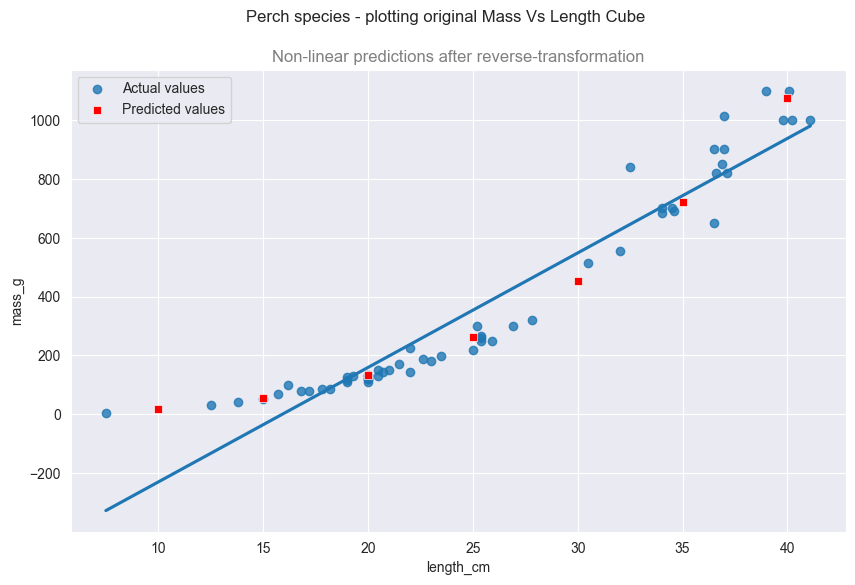

In [35]:
fig = plt.figure()
plt.figure(figsize=(10,6))
# Considering the original subset of the Perch sub-species
sns.regplot(data=perch_sp, x="length_cm", y="mass_g", ci=None, label="Actual values")
sns.scatterplot(data=perch_predctn, x="length_cm", y="mass_g", label="Predicted values", marker="s", color="red")
plt.suptitle("Perch species - plotting original Mass Vs Length Cube")
plt.title("Non-linear predictions after reverse-transformation",color='grey')
plt.show()


### Example 2-Using churn dataset
Using the earlier `cnvrsn_df` that contains:

**Impressions** are the total number of times your content is displayed, no matter if it was clicked or not.<br>
**Reach** is the total number of unique users who see your content.<br>
**Engagement** is the total number of times users interact with your content. This could be likes, comments, shares and **clicks**.

In [36]:
cnvrsn_df.head()

,spent_usd,n_impressions,n_clicks
0,1.43,7350,1
1,1.82,17861,2
2,1.25,4259,1
3,1.29,4133,1
4,4.77,15615,3


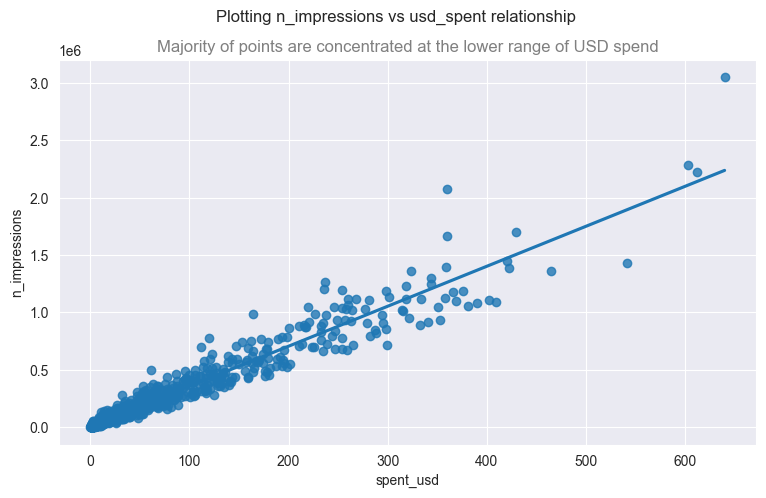

In [37]:
plt.figure(figsize=(9,5))
sns.regplot(data=cnvrsn_df, x="spent_usd", y="n_impressions", ci=None)
plt.suptitle("Plotting n_impressions vs usd_spent relationship")
plt.title("Majority of points are concentrated at the lower range of USD spend", color="grey")
plt.show()

As observed in above plot, Majority of the points are concentrated at the lower range of USD spends<br> i.e. **Data has a predominantly right-skewed distribution**.

In such case, we try taking square roots of the response & explanatory variables to see if linear regression fits the new columns.

In [38]:
cnvrsn_df["sqrt_spent_usd"] = np.sqrt(cnvrsn_df["spent_usd"])
cnvrsn_df["sqrt_n_impressions"] = np.sqrt(cnvrsn_df["n_impressions"])

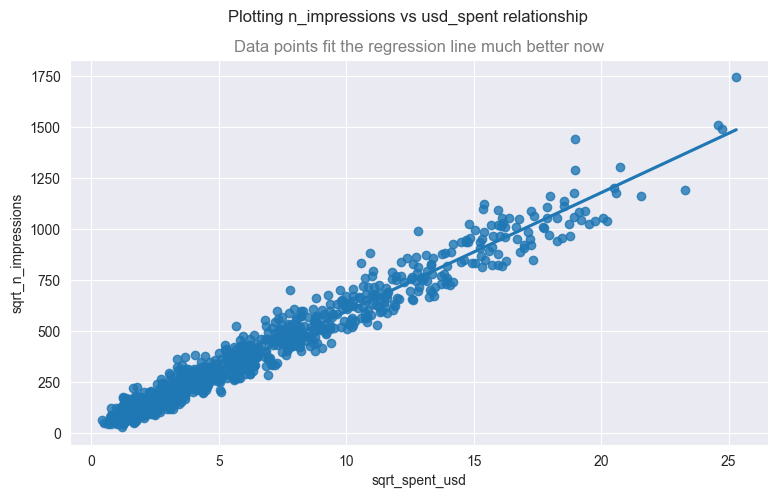

In [39]:
# Plotting now with the new columns
plt.figure(figsize=(9,5))
sns.regplot(data=cnvrsn_df, x="sqrt_spent_usd", y="sqrt_n_impressions", ci=None)
plt.suptitle("Plotting n_impressions vs usd_spent relationship")
plt.title("Data points fit the regression line much better now", color="grey")
plt.show()

In [40]:
# Fitting the regresison model & creating df for ex_vars
cnvrsn_mdl = ols("sqrt_n_impressions ~ sqrt_spent_usd", data=cnvrsn_df).fit()
cnvrsn_mdl.params

Intercept         15.319713
sqrt_spent_usd    58.241687
dtype: float64

This indicates decent correlation can be observed now **(~58%)** for `sqrt_n_impressions` vs `sqrt_spend_usd` after the square root transformation.

Now we can use sample explanatory values for prediction (can be checked with `describe()` method first). 

In [41]:
# checking the stats on the new column for selecting ex_vars 
print(cnvrsn_df["spent_usd"].describe().loc[["min","mean","max", "count"]])

# defining explanatory variables
cnvrsn_exvars = pd.DataFrame({"sqrt_spent_usd":np.sqrt(np.arange(0,601,100)),
                             "spent_usd":np.arange(0,601,100)})
cnvrsn_exvars


min        0.180000
mean      62.719263
max      639.949998
count    936.000000
Name: spent_usd, dtype: float64


,sqrt_spent_usd,spent_usd
0,0.000000,0
1,10.000000,100
2,14.142136,200
3,17.320508,300
4,20.000000,400
5,22.360680,500
6,24.494897,600


NOTE: Output of the `predict` will be square rt of `n_impressions` since thats the input given to the model.

So ,we need to 'undo' the transformation implemented earlier i.e square the `n_impressions` to get the final impresison values. This is called **Back-transformation**.

In [42]:
cnvrsn_predictions = cnvrsn_exvars.assign(sqrt_n_impressions = cnvrsn_mdl.predict(cnvrsn_exvars),
                                          n_impressions = cnvrsn_mdl.predict(cnvrsn_exvars)**2)

cnvrsn_predictions

,sqrt_spent_usd,spent_usd,sqrt_n_impressions,n_impressions
0,0.000000,0,15.319713,2.346936e+02
1,10.000000,100,597.736582,3.572890e+05
2,14.142136,200,838.981547,7.038900e+05
3,17.320508,300,1024.095320,1.048771e+06
4,20.000000,400,1180.153450,1.392762e+06
5,22.360680,500,1317.643422,1.736184e+06
6,24.494897,600,1441.943858,2.079202e+06


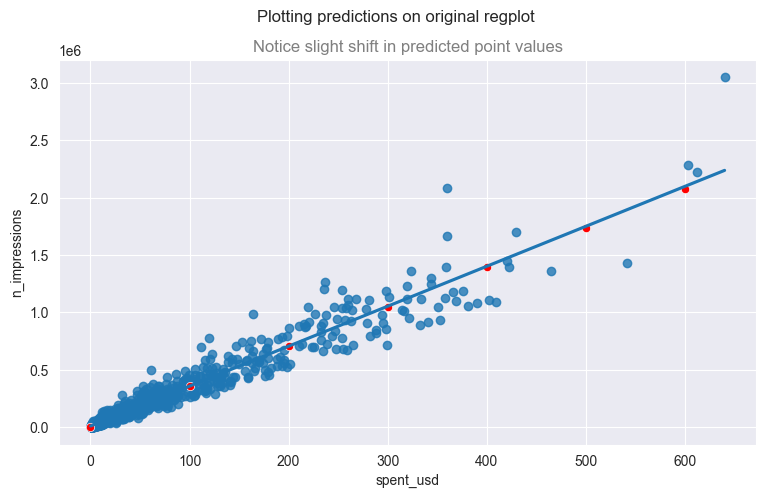

In [43]:
fig =  plt.figure(figsize=(9,5))
sns.regplot(data=cnvrsn_df, x="spent_usd", y="n_impressions", ci=None)
sns.scatterplot(data=cnvrsn_predictions, x="spent_usd",y="n_impressions", color="red")
plt.suptitle("Plotting predictions on original regplot")
plt.title("Notice slight shift in predicted point values", color="grey")
plt.show()

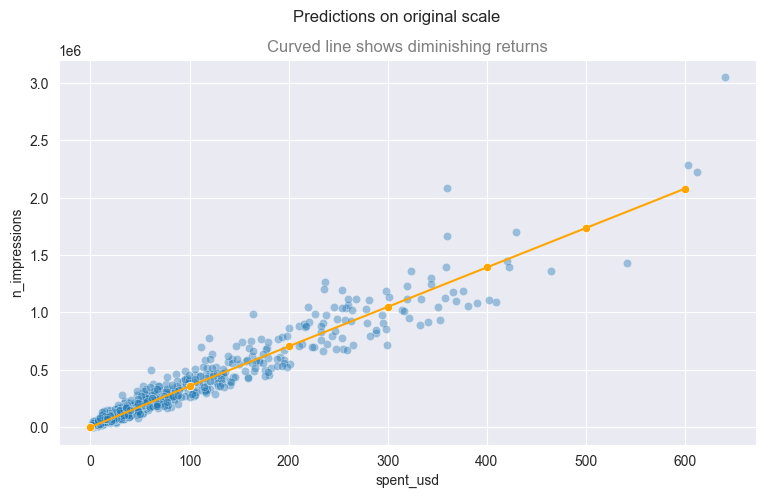

In [44]:
fig = plt.figure(figsize=(9,5))
sns.scatterplot(data=cnvrsn_df, x="spent_usd", y="n_impressions", alpha=0.4)
sns.lineplot(data=cnvrsn_predictions, x="spent_usd", y="n_impressions", color="orange")
sns.scatterplot(data=cnvrsn_predictions, x="spent_usd", y="n_impressions", color="orange")
plt.suptitle("Predictions on original scale")
plt.title("Curved line shows diminishing returns", color="grey")
plt.show()

In [45]:
# Generating more predicted values
cnvrsn_exvars1 = pd.DataFrame({"sqrt_spent_usd":np.sqrt(np.arange(0,801,20)),
                             "spent_usd":np.arange(0,801,20)})

cnvrsn_predictions1 = cnvrsn_exvars1.assign(sqrt_n_impressions = cnvrsn_mdl.predict(cnvrsn_exvars1),
                                          n_impressions = cnvrsn_mdl.predict(cnvrsn_exvars1)**2)
cnvrsn_predictions1.shape

(41, 4)

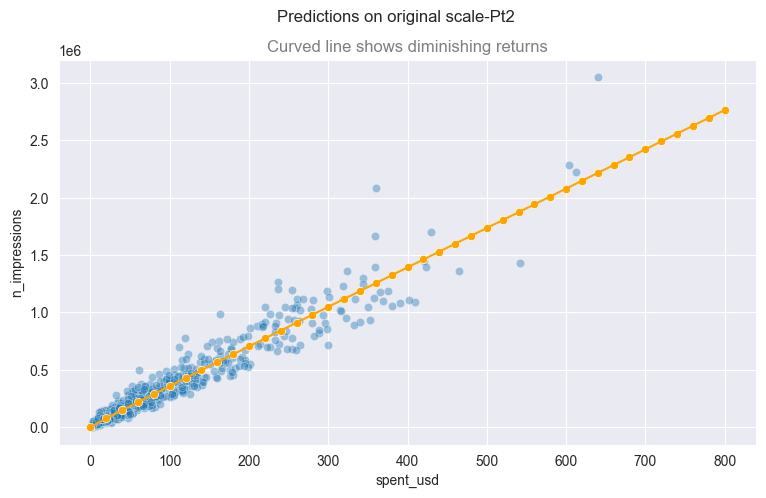

In [46]:
fig = plt.figure(figsize=(9,5))
sns.scatterplot(data=cnvrsn_df, x="spent_usd", y="n_impressions", alpha=0.4)
sns.lineplot(data=cnvrsn_predictions1, x="spent_usd", y="n_impressions", color="orange")
sns.scatterplot(data=cnvrsn_predictions1, x="spent_usd", y="n_impressions", color="orange")
plt.suptitle("Predictions on original scale-Pt2")
plt.title("Curved line shows diminishing returns", color="grey")
plt.show()

_____
## Quantifying model fit
Assess how well a linear regression model fits, diagnose model problems using visualizations, and understand each observation's leverage and influence to create the model.

### r-squared (Coffecient of determination)
Measures what proportion of the variation in y is explained by your model.


In [47]:
# r-squared valus of some previous models
print("R-Squared values for some previous models:\n")
print(f"Ad conversion model: {cnvrsn_mdl.rsquared.round(2)} \n-- indicates sqrt usd_spent explains 96% of variation in sqrt_impressions is explained by the model\n")

print(f"Bream sub-species: {mdl_mass_length.rsquared.round(2)} \n-- indicates ~88% of variation in mass is explained by the model")


R-Squared values for some previous models:

Ad conversion model: 0.96 
-- indicates sqrt usd_spent explains 96% of variation in sqrt_impressions is explained by the model

Bream sub-species: 0.88 
-- indicates ~88% of variation in mass is explained by the model


### Residuals
$R^2$ gives you a single number, but residual plots tell you what's actually going wrong.


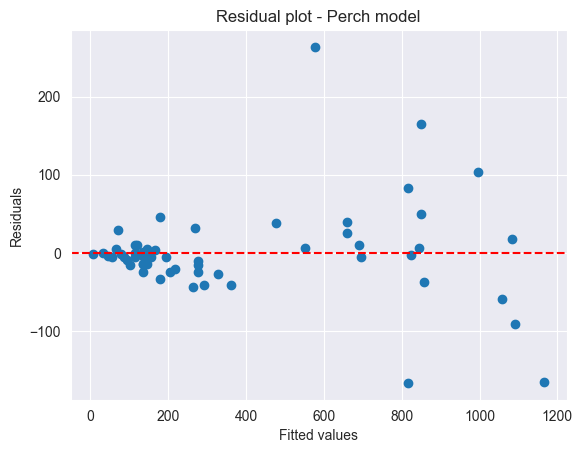

In [48]:
plt.scatter(perch_cblen_mdl.fittedvalues, perch_cblen_mdl.resid)
plt.axhline(0, color="red", linestyle="--")
plt.xlabel("Fitted values")
plt.ylabel("Residuals")
plt.title("Residual plot - Perch model")
plt.show()

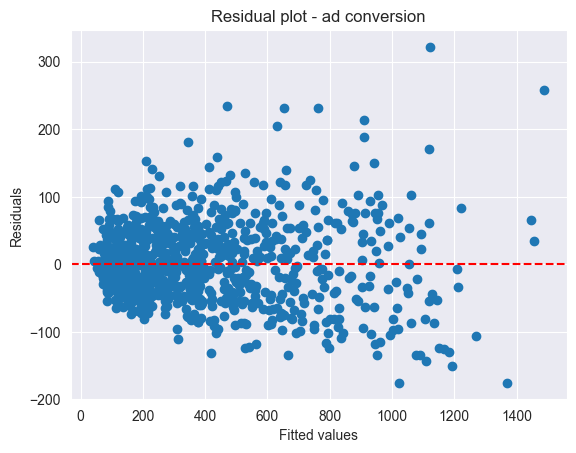

In [49]:
plt.scatter(cnvrsn_mdl.fittedvalues, cnvrsn_mdl.resid)
plt.axhline(0, color="red", linestyle="--")
plt.xlabel("Fitted values")
plt.ylabel("Residuals")
plt.title("Residual plot - ad conversion")
plt.show()

In [50]:
mdl_mass_length.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                 mass_g   R-squared:                       0.878
Model:                            OLS   Adj. R-squared:                  0.874
Method:                 Least Squares   F-statistic:                     237.6
Date:                Thu, 09 Apr 2026   Prob (F-statistic):           1.22e-16
Time:                        07:18:09   Log-Likelihood:                -199.35
No. Observations:                  35   AIC:                             402.7
Df Residuals:                      33   BIC:                             405.8
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept  -1035.3476    107.973     -9.589      0.000   -1255.020    -815.676
length_cm     54.5500      3.539     15.415      0.000      47.350      61.750
==============================================================================
Omnibus:                        7.314   Durbin-Watson:                   1.478
Prob(Omnibus):                  0.026   Jarque-Bera (JB):               10.857
Skew:                          -0.252   Prob(JB):                      0.00439
Kurtosis:                       5.682   Cond. No.                         263.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

# Visualizing Model Fit
There are several methods to visualize whether or not a model fit
### 1. Residual vs Fitted values
> _Shows Relationship between predicted values and errors_

The residuals of a good model fit will be randomly scattered about the zero-line. If model is good fit, there won't be any patterns in the plotting of the residuals - all indicating that Model captured the relationship well & that Errors are random

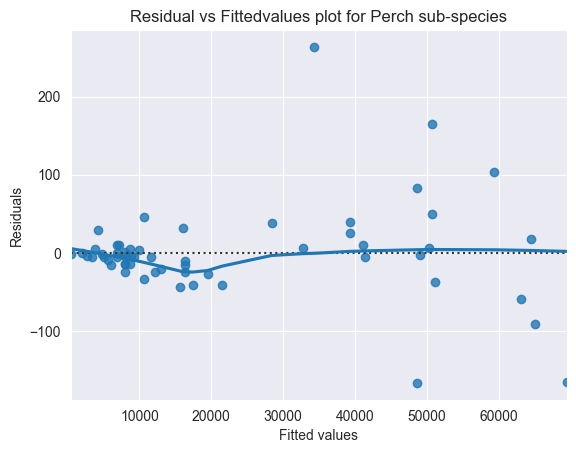

In [51]:
# Plot the residuals vs. fitted values
sns.residplot(x = "length_cm_cb", y = "mass_g", data=perch_sp, lowess=True)
plt.xlabel("Fitted values")
plt.ylabel("Residuals")
plt.title("Residual vs Fittedvalues plot for Perch sub-species")
plt.show()

Observations:

* The spread of residuals increases as fitted values grow — this is the funnel pattern, indicating heteroscedasticity. The model is less precise for heavier/longer fish than for smaller ones.
* Most points are squished between 0–20,000 on the x-axis — these are your smaller Perch. The model fits them reasonably well (residuals stay close to 0).
* Beyond fitted value ~35,000, residuals start swinging widely — +265, +160, −150, −175 — these are the larger Perch where the model struggles.
* The zero-line Stays very close to 0 across the full range — this is actually a good sign. It means there's no strong systematic curve or bias in the residuals, just increased variance at the high end.
* The length³ transformation fixed the non-linearity problem, but the heteroscedasticity remains — meaning the model is systematically less reliable for larger fish. A log transform on y (log(mass_g)) could potentially address this remaining issue.

### 2. Q-Q plot:
>_Helps identify whether residuals follow a normal distribution_

This plot compares the quantiles of residuals to a normal distribution, helping you assess if the residuals are normally distributed—a key assumption in linear regression. Points closely following a straight line indicate normal distribution of residuals.

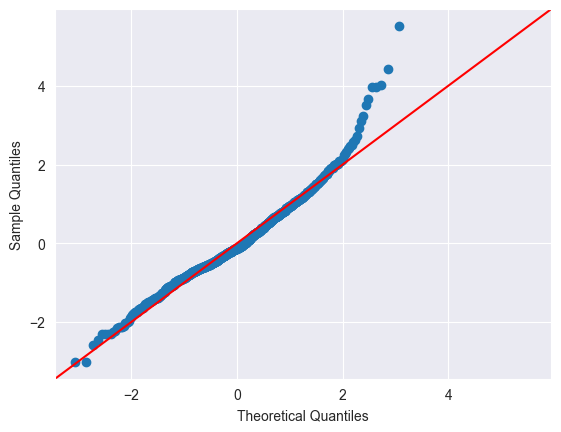

In [52]:
# Import qqplot
from statsmodels.api import qqplot

# Create the Q-Q plot of the residuals
qqplot(data=cnvrsn_mdl.resid, fit=True, line="45")

# Show the plot
plt.show()

### 3. Scale location plot

## Outliers, Leverage & Influence

`.get_influence()` in statsmodels is a method called on a fitted regression model (commonly OLS) to calculate diagnostic measures for identifying influential data points and outliers. It returns an `OLSInfluence` object containing metrics like Cook's distance, studentized residuals, and leverage (`hat_diag`) to evaluate how individual observations affect model parameters.

### Leverage: 
_Leverage measures how far a data point’s input value (X) is from the average of all X values._

A point has high leverage if its x value is far from the mean of x — regardless of whether it affects the line or not. Think of it like a physical lever — a point far out on the x-axis has more potential to move the line, just by virtue of its position.

>Use `.get_influence().summary_frame()` 's `hat_diag` column to get the leverage values. The column gives how near or extreme the values are.

In [53]:
perch_cblen_mdl.get_influence().summary_frame().head()

,dfb_Intercept,dfb_length_cm_cb,cooks_d,standard_resid,hat_diag,dffits_internal,student_resid,dffits
55,-0.003570,0.002648,0.000006,-0.017718,0.039719,-0.003603,-0.017553,-0.003570
56,-0.002200,0.001581,0.000002,-0.011369,0.036825,-0.002223,-0.011263,-0.002202
57,-0.012653,0.008951,0.000082,-0.066580,0.035615,-0.012795,-0.065963,-0.012676
58,-0.015606,0.010844,0.000125,-0.083822,0.034322,-0.015803,-0.083048,-0.015657
59,0.015546,-0.010668,0.000124,0.084654,0.033492,0.015759,0.083873,0.015613


In [54]:
# Obtaining only the hat matrix diagonal from influence model object
perch_influence = perch_cblen_mdl.get_influence()
perch_influence.hat_matrix_diag

array([0.03971914, 0.0368253 , 0.03561496, 0.03432205, 0.03349232,
       0.03286712, 0.03208294, 0.03154073, 0.03070051, 0.03012395,
       0.02893685, 0.02893685, 0.02893685, 0.02848181, 0.02740431,
       0.02740431, 0.02740431, 0.02740431, 0.02740431, 0.0266254 ,
       0.0266254 , 0.02631269, 0.02584323, 0.02506216, 0.024287  ,
       0.024287  , 0.02337207, 0.02277597, 0.02205209, 0.0200898 ,
       0.01985966, 0.01963866, 0.01963866, 0.01963866, 0.01912999,
       0.01833408, 0.01792893, 0.01923406, 0.02223869, 0.02371206,
       0.02983545, 0.02983545, 0.03251988, 0.03309942, 0.04714654,
       0.04714654, 0.04806135, 0.05092194, 0.05191501, 0.05191501,
       0.05292829, 0.07637044, 0.08890645, 0.09406418, 0.09584134,
       0.11320352])

In [55]:
type(perch_influence)

statsmodels.stats.outliers_influence.OLSInfluence

### Influence: 
`Influence = leverage (size of the residuals) + unusual y value combined.` <br>
A point is influential if removing it would significantly change the regression line. High leverage alone isn't enough — the point also needs to be off the trend.

Influence is measured using Cook's Distance - the most common influence metric. It measures how much all fitted values change if you remove that one point. 

>Ideally, Cook's D > 1 is a serious concern. Values > 0.5 worth investigating.
>Use `.get_influence().summary_frame()` 's `cooks_d` column to get the leverage values. The column gives how near or extreme the values are.

In [56]:
# Creating OLSInfluence object
perch_summ = perch_cblen_mdl.get_influence().summary_frame()
# Adding to original df of Perch sub-species
perch_sp["leverage"] = perch_summ["hat_diag"]
perch_sp["cooks_dist"] = perch_summ["cooks_d"]
perch_sp.head()

,species,mass_g,length_cm,length_cm_cb,leverage,cooks_dist
55,Perch,5.9,7.5,421.875,0.039719,0.000006
56,Perch,32.0,12.5,1953.125,0.036825,0.000002
57,Perch,40.0,13.8,2628.072,0.035615,0.000082
58,Perch,51.5,15.0,3375.000,0.034322,0.000125
59,Perch,70.0,15.7,3869.893,0.033492,0.000124


As observed below on sorting by Influence, data point with highest influence (cooks_dist) has an 'outlying' X-variable (explanatory variable) i.e. the species length of 41.1cm -- one of the extreme lengths in the dataset.

In [57]:
# Sorting by influence (Cook's distance)
print(perch_sp.sort_values("cooks_dist", ascending=False).head())
print("\n")
print(perch_sp["length_cm"].nlargest(5))

    species  mass_g  length_cm  length_cm_cb  leverage  cooks_dist
110   Perch  1000.0       41.1     69426.531  0.113204    0.523632
94    Perch   840.0       32.5     34328.125  0.023712    0.228271
104   Perch  1015.0       37.0     50653.000  0.051915    0.206126
100   Perch   650.0       36.5     48627.125  0.047147    0.190399
109   Perch  1000.0       40.2     64964.808  0.095841    0.128262


110    41.1
109    40.2
108    40.1
107    39.8
106    39.0
Name: length_cm, dtype: float64


## Impact of Leverage & Influence on the model:
visualizing the regression plots before & after removing the extreme value

In [58]:
perch_sp2 = perch_sp[perch_sp["length_cm"]!=41.1]
print(f"Original sub-df: {perch_sp.shape}")
print(f"Modified sub-df: {perch_sp2.shape}")


Original sub-df: (56, 6)
Modified sub-df: (55, 6)


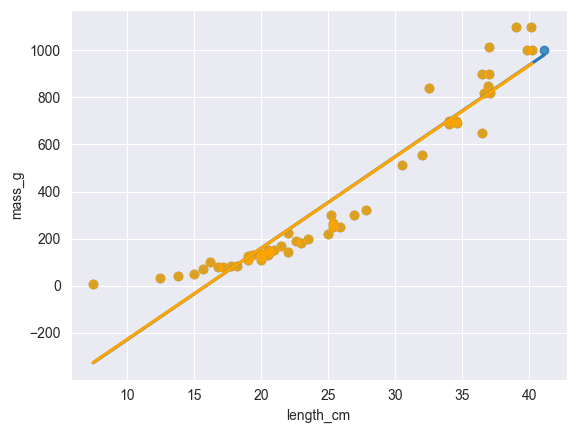

In [59]:
fig = plt.figure()
# Original 
sns.regplot(data=perch_sp, x="length_cm", y="mass_g", label="Original", ci=None)
# modified sub-df (removed highest influential X-value)
sns.regplot(data=perch_sp2, x="length_cm", y="mass_g", label="Original", ci=None, color="orange")

plt.show()

### How Residual is related to  Leverage & Influence:
Leverage → NOT directly related to residuals<br>
Influence → DIRECTLY depends on residuals (and leverage)

the relationship is nuance:<br>
* A point can have a large residual but zero influence — if its X-value is not in extremeties.
* However, a particular X-value could have low residual value but it could be far out on the X-axis that it could have considerable pull on the model. Removing such a point could move the regression line significantly

___
# EXAMPLE-Linear Regression-Taiwan housing dataset:

In [60]:
# Importing the dataset for Taiwan housing market
taiwan_hsg_mrkt = pd.read_csv('./datasets/taiwan_real_estate2.csv')
taiwan_hsg_mrkt.head()

,dist_to_mrt_m,n_convenience,house_age_years,price_twd_msq
0,84.87882,10,30 to 45,11.467474
1,306.59470,9,15 to 30,12.768533
2,561.98450,5,0 to 15,14.311649
3,561.98450,5,0 to 15,16.580938
4,390.56840,5,0 to 15,13.040847


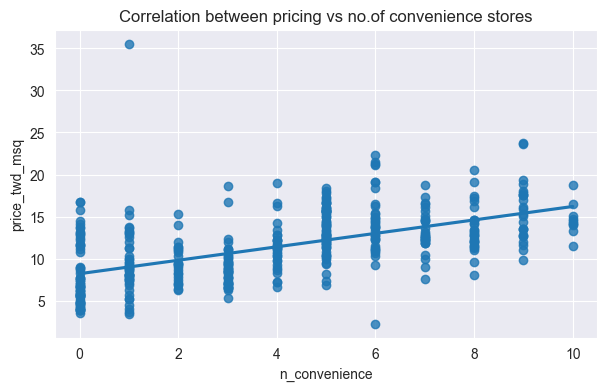

In [61]:
# Observing the pricing-no. of stores relationship
plt.figure(figsize = (7,4))
sns.regplot(data=taiwan_hsg_mrkt, x= "n_convenience", y="price_twd_msq", ci=None)
plt.title("Correlation between pricing vs no.of convenience stores")
plt.show()

In [62]:
mdl_taiwan_hsg_mrkt = ols("price_twd_msq ~ n_convenience" , data = taiwan_hsg_mrkt).fit()
mdl_taiwan_hsg_mrkt.params

Intercept        8.224237
n_convenience    0.798080
dtype: float64

The `params` result shows that:
* The intercept (b) is 8.22 - This is **price per sq.m even when there's no convenience store nearby**
* The slope (m) is 0.79 - This is the **rate of increase in pricing per sq.m when no. of nearby store increased by 1**

___
**Q** :<br>
The Taiwan real estate dataset has a categorical variable in the form of the age of each house.<br>
The ages have been split into 3 groups: 0 to 15 years, 15 to 30 years, and 30 to 45 years.

 Since the independent variable is a categorical, a good option is to draw a histogram for each category.<br>
Plot a histogram of `price_twd_msq` with 10 bins. Split the plot by `house_age_years` to give 3 panels.

**Ans** : <br>
It appears that new houses are the most expensive on average, and the medium aged ones (15 to 30 years) are the cheapest.

<Figure size 1000x800 with 0 Axes>

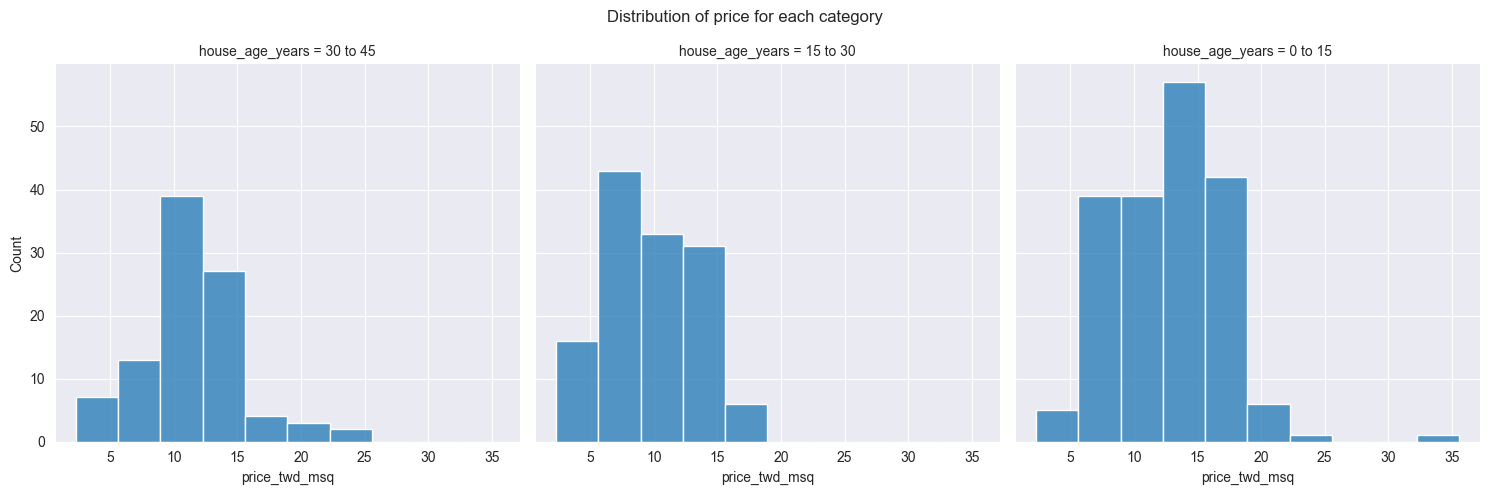

In [63]:
plt.figure(figsize=(10,8))
# Histograms of price_twd_msq with 10 bins, split by the age of each house
sns.displot(data=taiwan_hsg_mrkt,  x="price_twd_msq",  col="house_age_years", bins=10)
# Show the plot
plt.suptitle("Distribution of price for each category")
plt.tight_layout()
plt.show()

**Q**:<br>
Prove that the coefficients of a linear regression model with one categorical variable are the means of each category. 

**Ans**:<br>
The coefficients of the model are just the means of each category, verified by the groupby aggregation.


In [64]:
taiwan_hsg_mrkt.groupby("house_age_years")["price_twd_msq"].mean()

house_age_years
0 to 15     12.637471
15 to 30     9.876743
30 to 45    11.393264
Name: price_twd_msq, dtype: float64

In [65]:
mdl_twn_price_vsage = ols("price_twd_msq ~ house_age_years + 0", data=taiwan_hsg_mrkt).fit()
mdl_twn_price_vsage.params

house_age_years[0 to 15]     12.637471
house_age_years[15 to 30]     9.876743
house_age_years[30 to 45]    11.393264
dtype: float64

**Q**:<br>
Make predictions for the house prices in the Taiwan real estate dataset. <br>
`mdl_taiwan_hsg_mrkt` is the fitted linear regression model of house price versus number of convenience stores.<br>
Create a sample df of explanatory data, where n_convenience has values from zero to ten.<br>
Lastly, visualize the predictions against training data.

In [66]:
# Create explanatory_data 
explanatory_data = pd.DataFrame({'n_convenience': np.arange(0, 11)})
# Use mdl_price_vs_conv to predict with explanatory_data, call it price_twd_msq
price_twd_msq = mdl_taiwan_hsg_mrkt.predict(explanatory_data)
# Create prediction_data
prediction_data = explanatory_data.assign(price_twd_msq = price_twd_msq)
# Print the result
print(prediction_data)

    n_convenience  price_twd_msq
0               0       8.224237
1               1       9.022317
2               2       9.820397
3               3      10.618477
4               4      11.416556
5               5      12.214636
6               6      13.012716
7               7      13.810795
8               8      14.608875
9               9      15.406955
10             10      16.205035


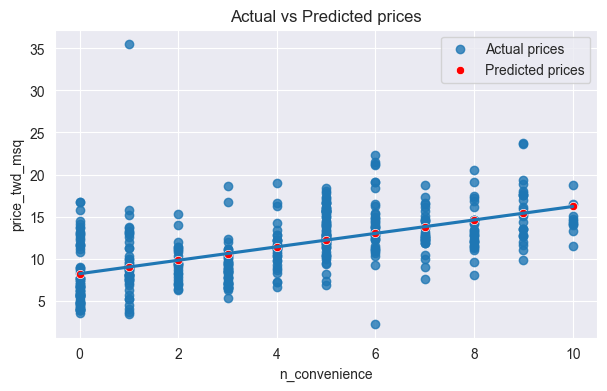

In [67]:
# Create a new figure, fig
fig = plt.figure(figsize=(7,4))
sns.regplot(x="n_convenience", y="price_twd_msq", data=taiwan_hsg_mrkt, ci=None, label="Actual prices")
# Add a scatter plot layer to the regplot
sns.scatterplot(data=prediction_data, x="n_convenience",y="price_twd_msq", color='red', label="Predicted prices")
plt.title("Actual vs Predicted prices")
# Show the layered plot
plt.show()

**Q: On variable transformation in regression**:
* Observe the current correlation between `housing_prices` & `distance_to nearest metro stn` & interpret the trend.
* Add a nw column to sqrt `distance  to nearest metro stn`. Use it to run a regression model.
* Now, Create a DataFrame of predictions & use it to predict prices with respect to distance.


sdf

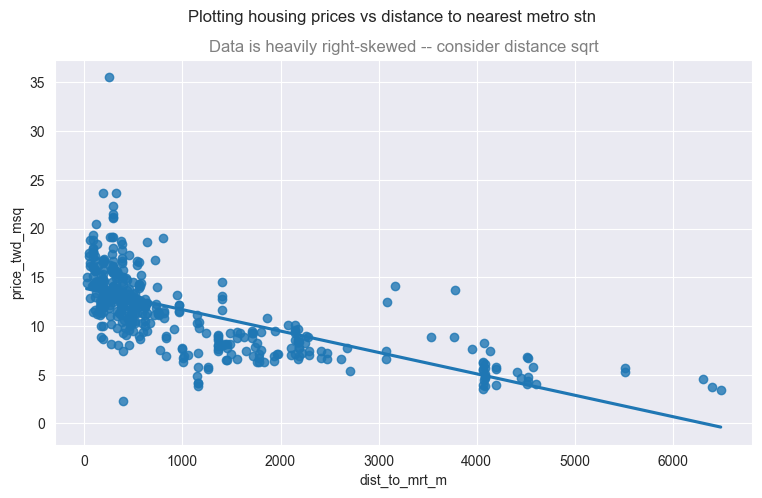

In [68]:
# check relationship between housing prices & distance to nearest metro station  
plt.figure(figsize=(9,5))
sns.regplot(data=taiwan_hsg_mrkt, x="dist_to_mrt_m" , y="price_twd_msq", ci=None)
plt.suptitle("Plotting housing prices vs distance to nearest metro stn")
plt.title("Data is heavily right-skewed -- consider distance sqrt", color="grey")
plt.show()

In [69]:
# Creating sqrt_dist_to_mrt_m
taiwan_hsg_mrkt["sqrt_dist_to_mrt_m"] = np.sqrt(taiwan_hsg_mrkt["dist_to_mrt_m"])

# Running a linear regression of price_twd_msq vs. sqrt_dist_to_mrt_m
twn_price_vsdist_mdl = ols("price_twd_msq ~ sqrt_dist_to_mrt_m", data=taiwan_hsg_mrkt).fit()
# Check the params
print(twn_price_vsdist_mdl.params)


Intercept             16.709799
sqrt_dist_to_mrt_m    -0.182843
dtype: float64


This indicates mild negative correlation between prices & distance to nearest mtero stn. This is expected since there are other factors that could be influencing housing prices.

Now, Create a DataFrame of explanatory variables (distance to nearest metro stn) & use it to predict property prices

In [70]:
twn_ex_vars = pd.DataFrame({"sqrt_dist_to_mrt_m": np.sqrt(np.arange(0, 81, 10) ** 2),
                                "dist_to_mrt_m": np.arange(0, 81, 10) ** 2})

# Use mdl_price_vs_dist to predict explanatory_data
twn_prediction_data = twn_ex_vars.assign(price_twd_msq = twn_price_vsdist_mdl.predict(twn_ex_vars))

print(twn_prediction_data)

   sqrt_dist_to_mrt_m  dist_to_mrt_m  price_twd_msq
0                 0.0              0      16.709799
1                10.0            100      14.881370
2                20.0            400      13.052942
3                30.0            900      11.224513
4                40.0           1600       9.396085
5                50.0           2500       7.567656
6                60.0           3600       5.739227
7                70.0           4900       3.910799
8                80.0           6400       2.082370


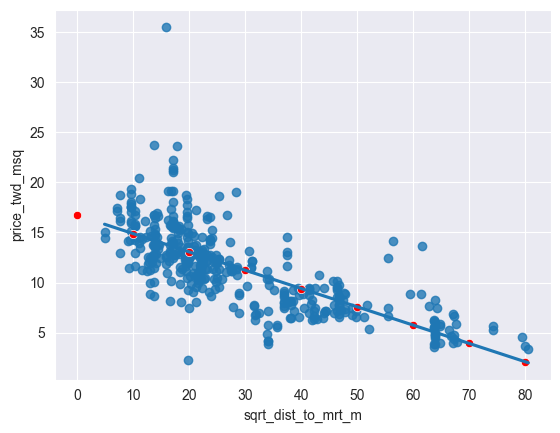

In [71]:
# Visualize the predictions against actual values
fig = plt.figure()
sns.regplot(x="sqrt_dist_to_mrt_m", y="price_twd_msq", data=taiwan_hsg_mrkt, ci=None)

# Add a layer of your prediction points
sns.scatterplot(data=twn_prediction_data, x="sqrt_dist_to_mrt_m", y="price_twd_msq", color="red")
plt.show()

In [72]:
mdl_mass_length.rsquared

np.float64(0.8780627095147174)

In [73]:
twn_price_vsdist_mdl.rsquared

np.float64(0.53274406146676)

Indicates that model accounts for only ~53% variations in price is explained by distance to MRT alone.<br>
This makes intuitive sense — many other factors (floor size, age, number of shops nearby) also drive housing prices. This isn't a bad model per se, just an incomplete one.

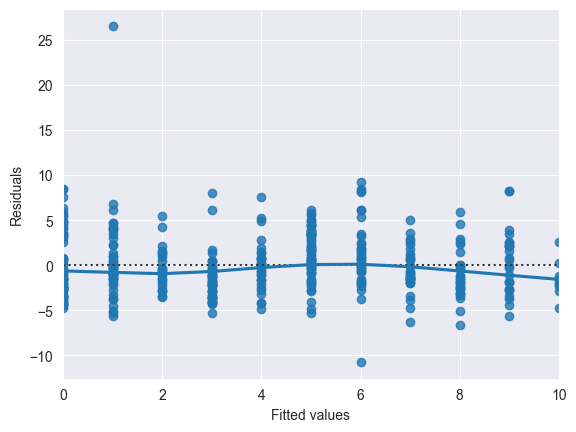

In [74]:
# Plot the residuals vs. fitted values
sns.residplot(x = "n_convenience", y = "price_twd_msq", data=taiwan_hsg_mrkt, lowess=True)
plt.xlabel("Fitted values")
plt.ylabel("Residuals")

# Show the plot
plt.show()

___
# EXAMPLE-Linear Regression-S&P500 dataset:

In [75]:
#tbd

____
# Logistic Regression
Logistic regression is a supervised machine learning algorithm used for binary classification, predicting the probability of an outcome that belongs to one of two classes (e.g., yes/no, 0/1).

It models the relationship between independent variables and a binary dependent variable by fitting an S-shaped sigmoid function, which maps any real-valued number into a probability value between 0 and 1.

In [76]:
churn_df = pd.read_csv("./datasets/churn.csv")
churn_df.head()

,has_churned,time_since_first_purchase,time_since_last_purchase
0,0,-1.089221,-0.721322
1,0,1.182983,3.634435
2,0,-0.846156,-0.427582
3,0,0.086942,-0.535672
4,0,-1.166642,-0.672640


<Figure size 1200x400 with 0 Axes>

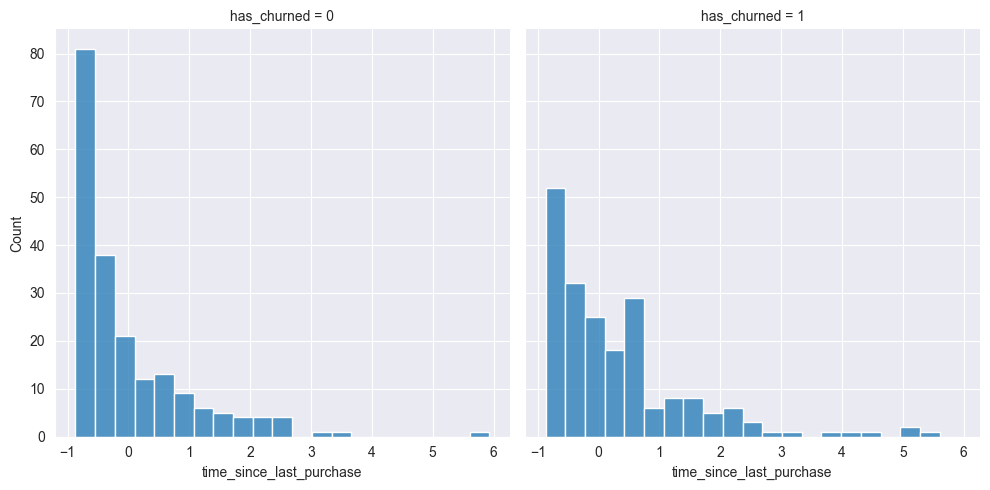

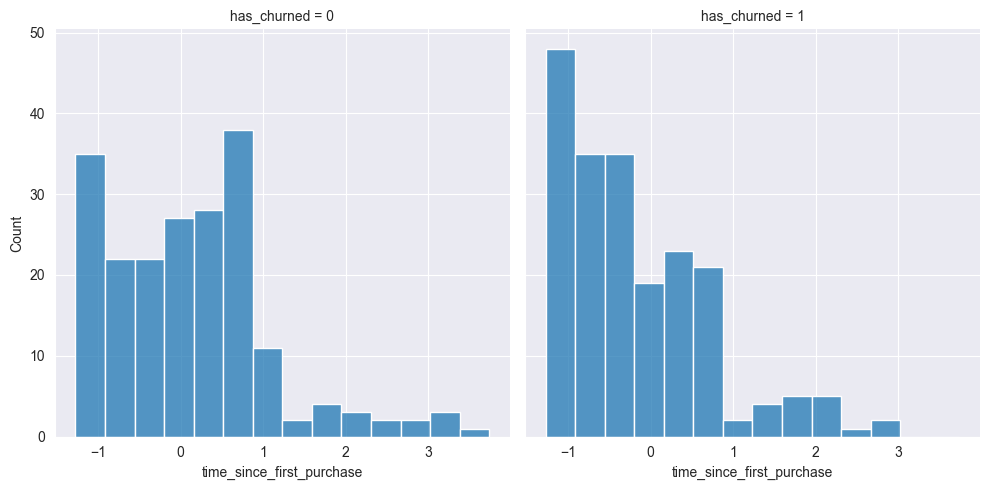

In [77]:
fig = plt.figure(figsize=(12,4))
# Create the histograms of time_since_last_purchase split by has_churned
sns.displot(data=churn_df, x="time_since_last_purchase", col="has_churned")
# Redraw the plot with time_since_first_purchase
sns.displot(data=churn_df, x="time_since_first_purchase", col="has_churned")

plt.show()

**Observation:**

In the `time_since_last_purchase` plot, the distribution of churned customers was further right than the distribution of non-churned customers (churners typically have longer times since their last purchase). For `time_since_first_purchase` the opposite is true: churners have a shorter length of relationship.

Running a Logistic regression model

In [78]:
# Import logit
from statsmodels.formula.api import logit

# Fit a logistic regression of churn vs. length of relationship using the churn dataset
mdl_churn_vs_relationship = logit("has_churned ~ time_since_first_purchase", data= churn_df).fit()

# Print the parameters of the fitted model
print(mdl_churn_vs_relationship.params)

Optimization terminated successfully.
         Current function value: 0.679663
         Iterations 4
Intercept                   -0.015185
time_since_first_purchase   -0.354795
dtype: float64


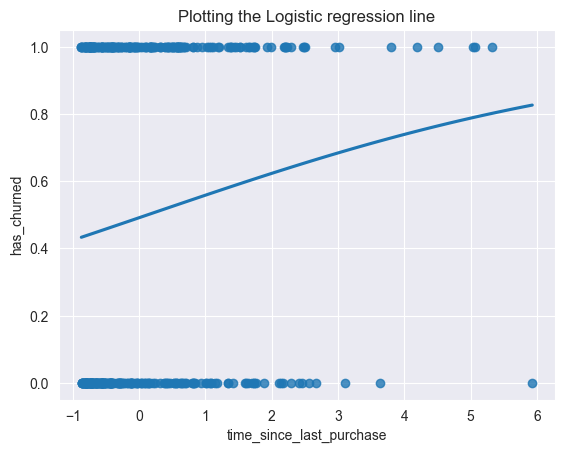

In [79]:
sns.regplot(x="time_since_last_purchase", y="has_churned", data=churn_df, ci=None, logistic=True)
plt.title("Plotting the Logistic regression line")
plt.show()

## Predicting values in Logistic regression
Its similar steps as followed for Logistic regression. This is will give us probability values (i.e. between 0 - 1) that dictates which customer will be most likely to churn.

In [80]:
# Creating  a model to fit most recent transactions by customers
mdl_recency = logit("has_churned ~ time_since_last_purchase", data = churn_df).fit()

Optimization terminated successfully.
         Current function value: 0.683000
         Iterations 4


In [81]:
# Creating df of explanatory variables
churn_exvars = pd.DataFrame({"time_since_last_purchase" : np.arange(-1,6.25,0.25)}) 

# Creating prediction dataframe
churn_predictions = churn_exvars.assign(has_churned = mdl_recency.predict(churn_exvars) )

churn_predictions.head()

,time_since_last_purchase,has_churned
0,-1.00,0.424523
1,-0.75,0.441043
2,-0.50,0.457695
3,-0.25,0.474441
4,0.00,0.491246


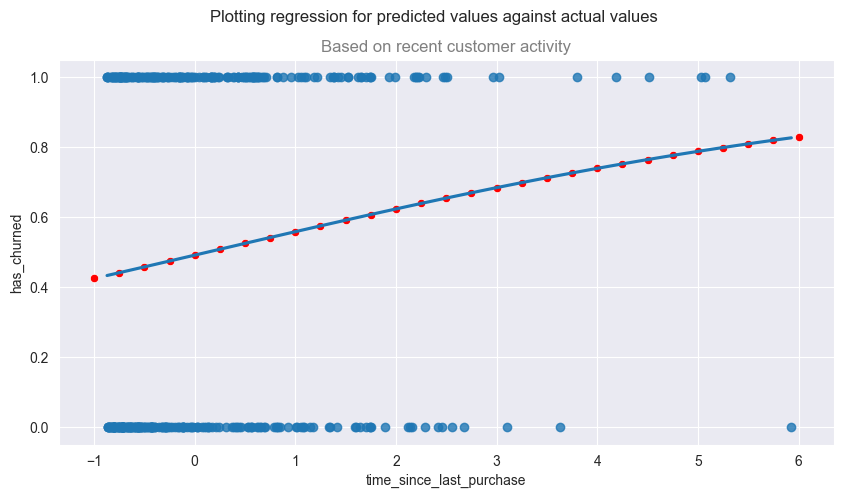

In [82]:
fig = plt.figure(figsize=(10,5))
sns.regplot(x="time_since_last_purchase", y="has_churned", data=churn_df, ci=None, logistic=True)
sns.scatterplot(x="time_since_last_purchase" , y="has_churned", data=churn_predictions, color="red")
plt.suptitle("Plotting regression for predicted values against actual values")
plt.title("Based on recent customer activity", color="grey")
plt.show()

## Getting most likely outcome:

Instead of $R^2$, Logistic regression uses 'maximum likelihood'.  

Customers with probability <0.5 are less likely to churn (i.e. has_churned for them would be 0). On the other hand, customers with churn probability >0.5 are more likely to churn.

To identify this, we simply round off the probabilities in churn predictions to 0 or 1.

In [83]:
churn_predictions["most_likely_outcome"] = np.round(churn_predictions["has_churned"])
churn_predictions.head()

,time_since_last_purchase,has_churned,most_likely_outcome
0,-1.00,0.424523,0.0
1,-0.75,0.441043,0.0
2,-0.50,0.457695,0.0
3,-0.25,0.474441,0.0
4,0.00,0.491246,0.0


### Visualizing the most likely outcome


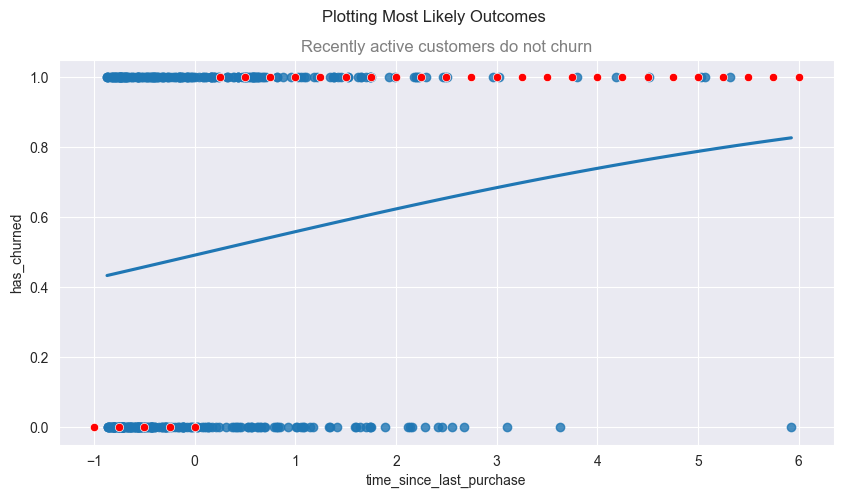

In [84]:
fig = plt.figure(figsize=(10,5))
sns.regplot(x="time_since_last_purchase", y="has_churned", data=churn_df, ci=None, logistic=True)
sns.scatterplot(x="time_since_last_purchase" , y="most_likely_outcome", data=churn_predictions, color="red")
plt.suptitle("Plotting Most Likely Outcomes")
plt.title("Recently active customers do not churn", color="grey")
plt.show()

Thus, it is clear that for most recently active customers, likely outcome is that they don't churn.

### Odds in Logistic regressions

Odds is the probability of an event has occurred divided by the probability that it has not.

In [85]:
churn_predictions["odds"] = churn_predictions["has_churned"] / (1 - churn_predictions["has_churned"])
churn_predictions.head()

,time_since_last_purchase,has_churned,most_likely_outcome,odds
0,-1.00,0.424523,0.0,0.737688
1,-0.75,0.441043,0.0,0.789046
2,-0.50,0.457695,0.0,0.843980
3,-0.25,0.474441,0.0,0.902738
4,0.00,0.491246,0.0,0.965587


### Visualizing odds
Odds cannot be plotted against actual values os we use logarithmic values of has_churned.

>The linear relationship between predicted log odds and the explanatory variable makes changes easier to reason about.

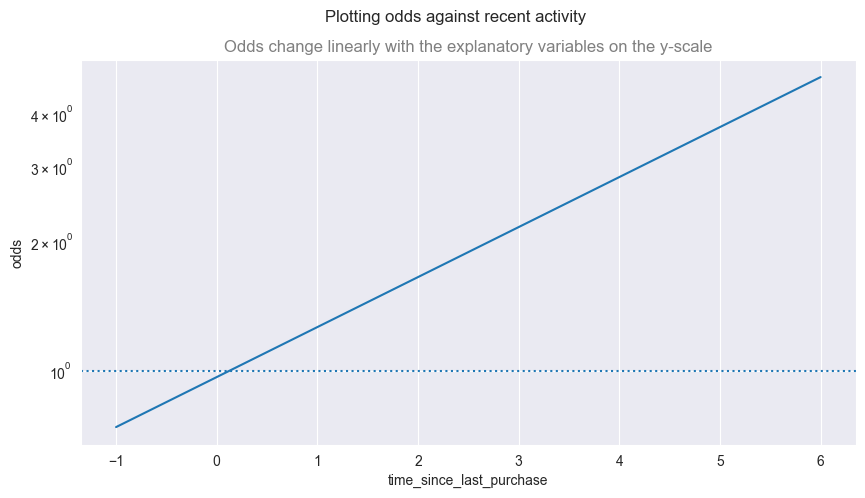

In [86]:
plt.figure(figsize=(10,5))
sns.lineplot(x="time_since_last_purchase", y="odds", data=churn_predictions)
plt.axhline(y=1, linestyle="dotted")
plt.suptitle("Plotting odds against recent activity")
plt.title("Odds change linearly with the explanatory variables on the y-scale", color="grey")
plt.yscale("log")
plt.show()

### Why is Log-unit scale used?
Odds are mathematically calculated as $\frac{p}{1 - p}$. **In logistic regression, We don't actually predict the probability directly in the internal math; we predict the Log-Odds**. 

Linear equations ($mx + b$) want to go from $-\infty\ to\ +\infty$. If we tried to fit a straight line to probability, the math would "break" at the boundaries of 0 and 1. To fix this, we transform the probability in two steps:<br>
**Odds Ratio:**<br>
We turn probability ($p$) into odds: $\frac{p}{1-p}$. (e.g. a $75$% chance is $3:1$ odds). This removes the upper limit of 1, but we are still stuck at a lower limit of 0.<br>
**The Log scale:** <br>
We then take the natural log of the odds ($Log-Odds$).<br>
**This "stretches" the values to range from $-\infty\ to\ +\infty$ & shows a linear relationship with the explanatory variable.**

### This is why it's called "Logit" (Logistic + Unit). 
By working in the log-scale, the model can use standard linear math to calculate coefficients & then "squish" the result back into a 0 to 1 probability at the very end.

In [87]:
churn_predictions["log_odds"] = np.log(churn_predictions["odds"])
churn_predictions.head()

,time_since_last_purchase,has_churned,most_likely_outcome,odds,log_odds
0,-1.00,0.424523,0.0,0.737688,-0.304234
1,-0.75,0.441043,0.0,0.789046,-0.236931
2,-0.50,0.457695,0.0,0.843980,-0.169627
3,-0.25,0.474441,0.0,0.902738,-0.102323
4,0.00,0.491246,0.0,0.965587,-0.035019


## Quantifying Logistic regression
### Understanding the confusion matrix

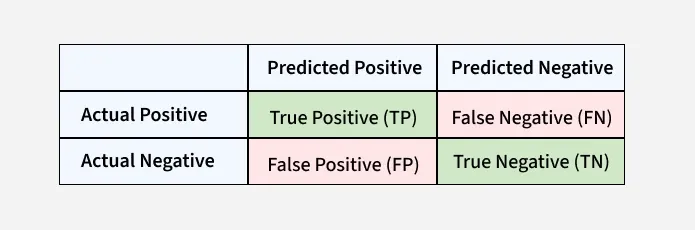

In [89]:
actual_response = churn_df["has_churned"]
predicted_response = np.round(mdl_recency.predict())

# Creating the confusion matrix
outcomes = pd.DataFrame({"actual_response": actual_response, "predicted_response": predicted_response})
print(outcomes.value_counts(sort=False))

actual_response  predicted_response
0                0.0                   141
                 1.0                    59
1                0.0                   111
                 1.0                    89
Name: count, dtype: int64


Observation:
* The model predicted 141 customers did not churn (True Negative) & 89 customers did churn(True Positive).
* Also, there were 59 False Positives & 111 False negatives.

In [94]:
# Array form of the confusion matrix
conf_matrix = mdl_recency.pred_table()
print(conf_matrix)

[[141.  59.]
 [111.  89.]]


(<Figure size 640x480 with 3 Axes>, {('0', '0'): (0.0, np.float64(0.0), 0.49751243781094534, np.float64(0.70265780730897)), ('0', '1'): (0.0, np.float64(0.7059800664451826), 0.49751243781094534, np.float64(0.2940199335548173)), ('1', '0'): (0.5024875621890548, np.float64(0.0), 0.49751243781094534, np.float64(0.553156146179402)), ('1', '1'): (0.5024875621890548, np.float64(0.5564784053156145), 0.49751243781094534, np.float64(0.4435215946843853))})


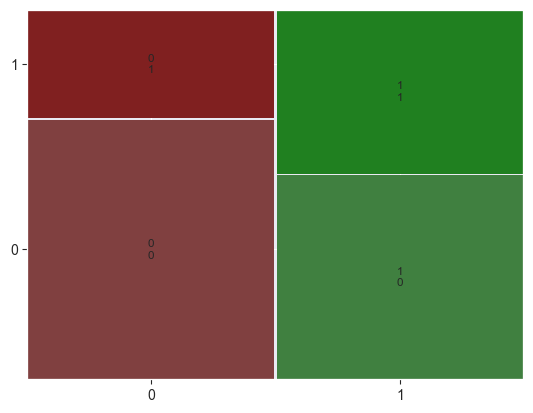

In [93]:
# Visualizing confusion matrix
from statsmodels.graphics.mosaicplot import mosaic

print(mosaic(mdl_recency.pred_table()))

Visualizes the previous results of the `pred_table()` function. 

## Accuracy
The porportion of correct predictions :

$\frac{TN + TP}{TP + FP + TN + FN}$

## Sensitivity
The proportion of True Positives from total Positive predictions of the model (TP + FN) : $\frac{TP}{TP + FN}$

## Specificity
The proportion of True Negatives from total False predictions of the model (FP + TN): $\frac{TN}{TN + FP}$
